<img src="./mse_logo.png" width="340" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# **Group 4: Univariate Feature Selection**

- Why feature selection helps (bias–variance tradeoff) (hesu)
- Univariate feature selection:
    - Pearson correlation
    - F-regression
    - MIC
    - χ2


## 1. Why feature selection helps (bias–variance tradeoff)

### Background

Every supervised model makes predictions that deviate from the truth for two distinct reasons:

| Source | Cause | Symptom |
|--------|-------|---------|
| **Bias** | Model is too simple to capture the true signal | Underfitting — high error on *both* train and test |
| **Variance** | Model is too sensitive to the particular training sample | Overfitting — low train error, high test error |

The **expected test error** decomposes as:

$$\text{Test Error} = \text{Bias}^2 + \text{Variance} + \sigma^2_\epsilon$$

where $\sigma^2_\epsilon$ is irreducible noise. We cannot eliminate the noise term, but we *can* control bias and variance through modelling choices — including which features we feed the model.

---

### Why irrelevant features increase variance

When the model sees *irrelevant* (noise) features it can detect spurious patterns that happen to correlate with $y$ in the training data but do not generalise (*Spurious patterns: are apparent relationships in the training data that look statistically meaningful but are actually caused by random chance — they don't reflect any true underlying structure.*).  
This raises **variance** without lowering bias:

- Each additional irrelevant feature adds one degree of freedom.
- The model uses that freedom to fit noise → training error ↓, test error ↑.
- In linear models the effect is mild; in flexible models (trees, kNN, …) it can be severe.

**Feature selection** removes irrelevant features, shrinking the hypothesis space (*model get simpler*) and thereby reducing variance — usually at the cost of a small, acceptable increase in bias.

> **Rule of thumb:** a model with $d$ features has $O(d)$ parameters to estimate. Fewer parameters → lower variance → better generalisation (everything else equal).


### Example: Adding noise features drives up test error

We generate a dataset where **only one feature is truly predictive** ($y = 2x_0 + \varepsilon$) and then progressively add pure noise features.  
A linear regression model is trained on all features; the 5-fold cross-validation MSE (proxy for test error) is tracked alongside the in-sample training error.


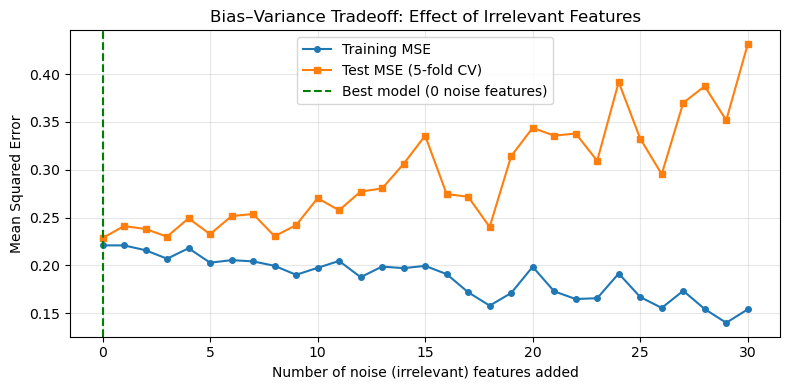

Test MSE with 0 noise features : 0.2285
Test MSE with 30 noise features: 0.4313


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

np.random.seed(42)
n_samples = 100

# Ground truth: only x0 matters
X0 = np.random.randn(n_samples, 1)
y = 2.0 * X0[:, 0] + np.random.randn(n_samples) * 0.5

max_noise_features = 30
n_noise_range = range(0, max_noise_features + 1)

train_errors, test_errors = [], []

for n_noise in n_noise_range:
    if n_noise == 0:
        X = X0
    else:
        X_noise = np.random.randn(n_samples, n_noise)
        X = np.hstack([X0, X_noise])

    model = LinearRegression()

    # In-sample (training) error
    model.fit(X, y)
    train_mse = np.mean((model.predict(X) - y) ** 2)
    train_errors.append(train_mse)

    # Out-of-sample error via 5-fold CV
    cv_mse = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error").mean()
    test_errors.append(cv_mse)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(n_noise_range, train_errors, label="Training MSE", marker="o", markersize=4)
ax.plot(n_noise_range, test_errors,  label="Test MSE (5-fold CV)", marker="s", markersize=4)
ax.axvline(x=0, color="green", linestyle="--", linewidth=1.5,
           label="Best model (0 noise features)")

ax.set_xlabel("Number of noise (irrelevant) features added")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Bias–Variance Tradeoff: Effect of Irrelevant Features")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Test MSE with 0 noise features : {test_errors[0]:.4f}")
print(f"Test MSE with {max_noise_features} noise features: {test_errors[-1]:.4f}")


#### Interpretation

- **Training error** (blue) decreases as more features are added — the model fits the training data increasingly well.
- **Test error** (orange) *rises* after the optimal point — the model starts to memorise noise, i.e. **variance increases**.
- The green dashed line marks the model that uses **only the one relevant feature**: it achieves the lowest test error.

This illustrates the core motivation for feature selection: removing irrelevant features keeps variance in check and yields a model that generalises better to unseen data.

> **Takeaway:** Feature selection is not just a computational shortcut — it is a principled way to shift the bias–variance balance toward lower generalisation error.


## 2. Pearson Correlation:

### Definition:
The Pearson correlation coefficient (r or p) is a parametric statistic, measuring the strength and direction of a linear relationship between two continuous, normally distributed variables. It ranges from -1 to +1, where +1 is a perfect positive correlation, -1 is a perfect negative correlation, and 0 indicates no linear relationship.

### Limitations:
It only detects linear relationships and is sensitive to outliers. Non-linear relationships are not detected.

### Application in ML:
Pearson correlation is a simple and fast way to evaluate feature relevance before training a model. By removing features with low correlation to the target or high correlation with other features. It can be used to reduce noise and improve training efficiency. It is especially useful in early exploratory data analysis (EDA).


### Formula:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

Where:
- $x_i, y_i$ are the individual sample points
- $\bar{x}, \bar{y}$ are the mean values of $X$ and $Y$
- $n$ is the number of samples

#### Correlation ≠ causation
https://www.tylervigen.com/spurious-correlations

### Example: 

| Person | Shoe size | Study hours | Exam score |
|------|------|------|------|
| 1 | 38 | 1 | 52 |
| 2 | 41 | 2 | 55 |
| 3 | 39 | 3 | 61 |
| 4 | 44 | 4 | 65 |
| 5 | 42 | 5 | 70 |
| 6 | 37 | 6 | 75 |

Pearson correlation between Shoe size and Exam score: 0.0172
Pearson correlation between Study hours and Exam score: 0.9977

Correlation matrix:


,Shoe size,Study hours,Exam score
Shoe size,1.000000,0.060754,0.017248
Study hours,0.060754,1.000000,0.997703
Exam score,0.017248,0.997703,1.000000


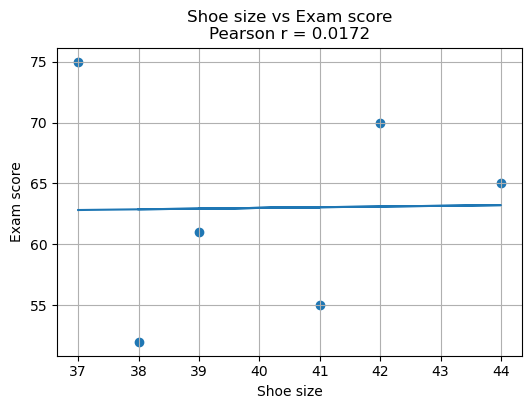

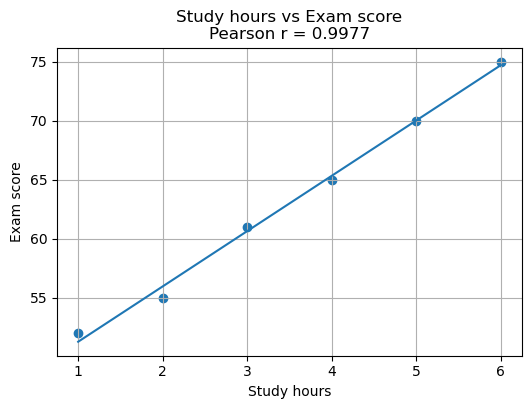

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Example dataset
# -----------------------------
df = pd.DataFrame({
    "Person": [1, 2, 3, 4, 5, 6],
    "Shoe size": [38, 41, 39, 44, 42, 37],
    "Study hours": [1, 2, 3, 4, 5, 6],
    "Exam score": [52, 55, 61, 65, 70, 75]
})

# -----------------------------
# Pearson correlation calculations
# -----------------------------
corr_shoe_exam = df["Shoe size"].corr(df["Exam score"])
corr_study_exam = df["Study hours"].corr(df["Exam score"])

print(f"Pearson correlation between Shoe size and Exam score: {corr_shoe_exam:.4f}")
print(f"Pearson correlation between Study hours and Exam score: {corr_study_exam:.4f}")

print("\nCorrelation matrix:")
display(df[["Shoe size", "Study hours", "Exam score"]].corr())

# -----------------------------
# Plot 1: Shoe size vs Exam score with trend line
# -----------------------------
x1 = df["Shoe size"]
y1 = df["Exam score"]
m1, b1 = np.polyfit(x1, y1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x1, y1)
plt.plot(x1, m1 * x1 + b1)
plt.xlabel("Shoe size")
plt.ylabel("Exam score")
plt.title(f"Shoe size vs Exam score\nPearson r = {corr_shoe_exam:.4f}")
plt.grid(True)
plt.show()

# -----------------------------
# Plot 2: Study hours vs Exam score with trend line
# -----------------------------
x2 = df["Study hours"]
y2 = df["Exam score"]
m2, b2 = np.polyfit(x2, y2, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x2, y2)
plt.plot(x2, m2 * x2 + b2)
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title(f"Study hours vs Exam score\nPearson r = {corr_study_exam:.4f}")
plt.grid(True)
plt.show()


## 3. F-Regression for Feature Selection

F-regression measures the **linear correlation** between each feature and the target variable _independently_, then ranks features by statistical significance.

### How it works

For each feature $X_i$​, it fits a simple linear regression against target $y$, then computes an **F-statistic**:
$$F = \frac{\text{variance explained by } X_i}{\text{residual variance}}$$

Total Variance is split into 2 buckets:
- variance explained by $X_i$
	- How much of that spread can be *accounted for* by the fitted line $\hat{y} = a + bX_i$?
- residual variance
	- What's _left over_ — the spread the line couldn't explain?

### Interpretation

A high F → strong linear relationship → feature is likely useful. 

It also gives a **p-value** - the probability of observing that F by chance if there were truly no relationship.

> Think of it like a "signal-to-noise ratio" per feature: how much does knowing $X_i$​ reduce your uncertainty about $y$, compared to random noise?

### Key caveat

F-regression is **univariate** — it evaluates each feature in isolation. It misses interaction effects (e.g. $X_1 \cdot X_2$​ being useful together but neither alone) and redundancy (two highly correlated features both scoring high).

### Code Examples

**1. Basic usage — get scores & p-values**

In [9]:
from sklearn.feature_selection import f_regression
import numpy as np

X = np.array([[1,2,10], [2,4,9], [3,6,8], [4,8,7], [5,10,6]])
y = np.array([1, 2, 3, 4, 5])

f_scores, p_values = f_regression(X, y)
# Feature 0: F=∞ (perfect linear), Feature 1: F=∞, Feature 2: F=∞ (perfect negative)
# In practice, scores vary — higher F = more linearly related to y

**2. SelectKBest — keep top-k features**

In [10]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=10, n_informative=3, noise=10)

selector = SelectKBest(score_func=f_regression, k=3)
X_reduced = selector.fit_transform(X, y)  # shape: (100, 3)

print(selector.get_support(indices=True))  # indices of selected features

[1 4 9]


**3. Inside a Pipeline (the right way)**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipe = Pipeline([
    ("select", SelectKBest(f_regression, k=5)),
    ("model",  Ridge())
])

pipe.fit(X, y)# pipe.fit(X_train, y_train)  # --- IGNORE ---

# Feature selection only sees training data — no leakage

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('select', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...x7f670c3299e0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",5
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) 

**4. Visualizing scores**

<Axes: title={'center': 'F-scores per feature'}>

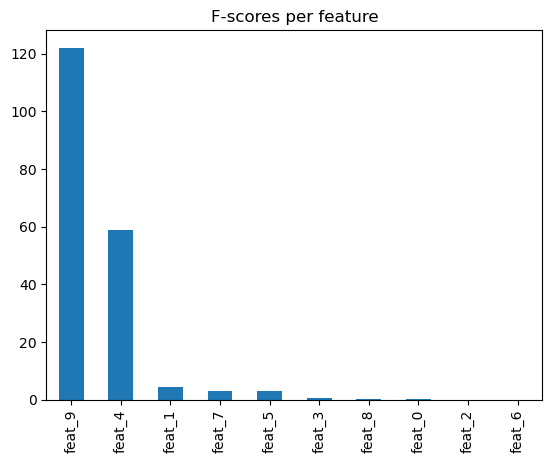

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

scores, pvals = f_regression(X, y)
pd.Series(scores, index=[f"feat_{i}" for i in range(X.shape[1])]) \
  .sort_values(ascending=False) \
  .plot(kind="bar", title="F-scores per feature")

# 4.MIC 


## Maximal Information Coefficient (MIC)

The **Maximal Information Coefficient (MIC)** is a statistical measure designed to detect both **linear and nonlinear relationships** between variables. It belongs to the **MINE (Maximal Information-based Nonparametric Exploration)** family of statistics and is based on the concept of **mutual information** from information theory.

The core idea of MIC is to search over many possible grid partitions of two variables and compute the **maximum normalized mutual information** achievable by any grid. This produces a score between **0 and 1**, where:

- **0** indicates no detectable relationship
- **1** indicates a strong functional relationship

### Comparison with Other Dependency Measures

| Method | Detects Nonlinear Relationships | Normalized | Typical Use |
|------|------|------|------|
| Pearson Correlation | No | Yes | Linear dependence |
| Mutual Information | Yes | No | General statistical dependence |
| MIC | Yes | Yes | Pattern discovery and exploratory analysis |

**Pearson correlation** only measures linear relationships and may fail when dependencies are nonlinear.  
**Mutual information** measures general dependency but is not normalized, making comparisons between relationships difficult.  
**MIC** addresses this by normalizing the dependency score, allowing relationships of different shapes to be compared more consistently.

### Relevance for Feature Engineering

Measures based on mutual information, including MIC, are useful in **feature selection and exploratory data analysis** because they can detect predictive relationships that are **not linearly correlated with the target variable**. This helps identify informative features that traditional correlation-based methods might miss.

             feature  pearson_corr  mutual_information
0     linear_feature      0.773828            0.538902
1  quadratic_feature     -0.010839            0.268394
2      noise_feature     -0.001328            0.000000


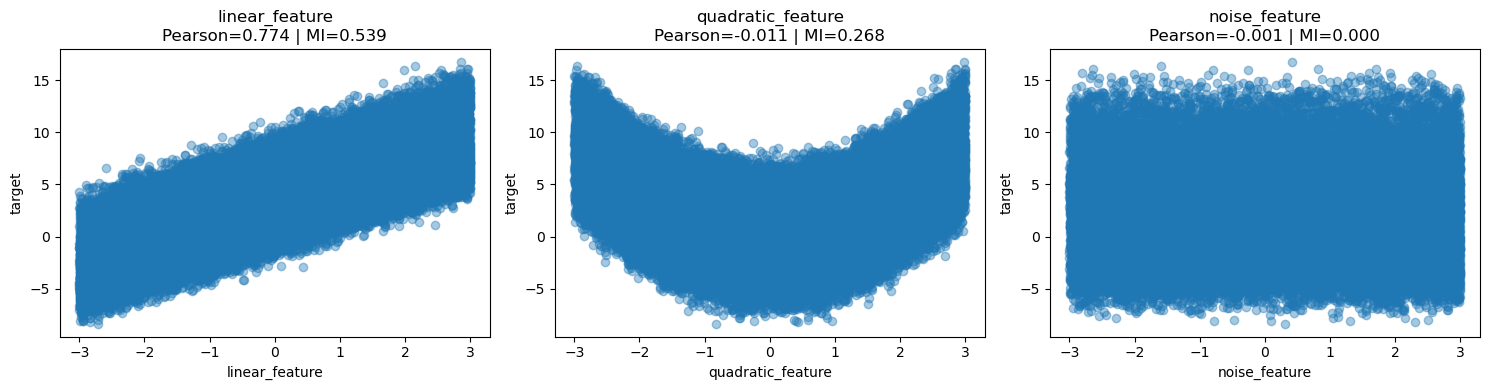

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr

np.random.seed(0)

n = 34022

# Features
x_linear = np.random.uniform(-3, 3, n)
x_quadratic = np.random.uniform(-3, 3, n)
x_noise = np.random.uniform(-3, 3, n)

# Target
y = 2 * x_linear + x_quadratic**2 + np.random.normal(0, 1, n)

X = pd.DataFrame({
    "linear_feature": x_linear,
    "quadratic_feature": x_quadratic,
    "noise_feature": x_noise
})

# ---- compute metrics ----

pearson_scores = [pearsonr(X[col], y)[0] for col in X.columns]
mi_scores = mutual_info_regression(X, y)

results = pd.DataFrame({
    "feature": X.columns,
    "pearson_corr": pearson_scores,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

print(results)

# convert results for easier lookup in plots
score_lookup = results.set_index("feature")

# ---- plotting ----

fig, axes = plt.subplots(1, 3, figsize=(15,4))

features = [
    ("linear_feature", x_linear),
    ("quadratic_feature", x_quadratic),
    ("noise_feature", x_noise)
]

for ax, (name, values) in zip(axes, features):
    
    pearson = score_lookup.loc[name, "pearson_corr"]
    mi = score_lookup.loc[name, "mutual_information"]

    ax.scatter(values, y, alpha=0.4)
    ax.set_title(
        f"{name}\nPearson={pearson:.3f} | MI={mi:.3f}"
    )
    ax.set_xlabel(name)
    ax.set_ylabel("target")

plt.tight_layout()
plt.show()

# 5.Chi-Square (χ²) for Feature Selection

## Chi-Square (χ²) for Feature Selection

The **chi-square test** is used in machine learning to measure whether a feature is related to the target variable. It is mainly useful for **classification tasks** with **categorical, binary, or count-based features**, for example word counts in text classification.

A **high χ² score** means the feature and the target are more strongly related, so the feature may be useful. A **low χ² score** means the feature is closer to being independent from the target. The main strengths of χ² are that it is **fast, simple, and easy to interpret**. Its main weaknesses are that it works **only on one feature at a time**, does **not capture feature interactions**, and is **not directly suitable for continuous raw values or negative values**.

The formula is:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

where:
- \(O\) = observed frequency
- \(E\) = expected frequency under independence

In [14]:
import pandas as pd
from sklearn.feature_selection import chi2

# Example data: binary word features for spam classification
X = pd.DataFrame({
    "contains_free":  [1, 1, 1, 0, 0, 0, 1, 0],
    "contains_money": [1, 1, 0, 0, 0, 0, 1, 0],
    "contains_hello": [0, 1, 0, 1, 1, 0, 0, 1]
})

# Target: 1 = Spam, 0 = Not Spam
y = pd.Series([1, 1, 1, 0, 0, 0, 1, 0], name="Spam")

# Compute chi-square scores
scores, p_values = chi2(X, y)

results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": scores,
    "p-value": p_values
}).sort_values("Chi2 Score", ascending=False)

print(results)

          Feature  Chi2 Score   p-value
0   contains_free         4.0  0.045500
1  contains_money         3.0  0.083265
2  contains_hello         1.0  0.317311


# **Conclusion**

## What should every ML practitioner remember?

- Feature selection helps **reduce noise and dimensionality**, improving model performance and training efficiency.
- Different methods detect **different types of relationships**:
  - **Pearson correlation** → linear relationships between continuous variables
  - **F-regression** → significance of linear relationships in regression
  - **χ² (Chi-square)** → dependency between categorical variables
  - **MIC** → detects linear and nonlinear relationships
- Methods evaluate **features individually**, so interactions between features may be missed.

---

## Common pitfalls

- **Using the wrong method for the data type**
  - Pearson / F-regression → continuous variables  
  - χ² → categorical variables
- **Missing nonlinear relationships** (Pearson and F-regression detect only linear patterns)
- **Sensitivity to outliers**, especially for Pearson correlation
- **Correlation does not imply causation**, see [Spurious Correlations Example](https://www.tylervigen.com/spurious-correlations)

---

## When does this technique really matter?

- During **exploratory data analysis (EDA)** to quickly identify relevant features
- For **high-dimensional datasets** to remove irrelevant features
- For **linear models**, where feature relationships directly affect performance
- In **preprocessing pipelines** before model training

---

## Method comparison

| Method | Data type | Detects | Typical use |
|------|------|------|------|
| Pearson | Continuous | Linear relationships | Quick filtering, multicollinearity |
| F-regression | Continuous | Linear dependency | Feature ranking in regression |
| MIC | Continuous | Linear & nonlinear relationships | Complex patterns |
| χ² | Categorical | Statistical dependency | Classification with categorical data |